# Part_2_Conservative_Propagation

In [1]:
# PART 2 — Conservative Layer-wise Relevance Propagation
# This notebook applies Conservative Propagation (Ali et al., 2022) to interpret emotion predictions.

from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

# Load model and tokenizer from local directory
model_path = "./camembert_model_6"
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(model_path, local_files_only=True)
model.eval()

# 18 predefined example sentences grouped by emotion
sentences_by_emotion = {
    "happiness": [
        "Il est super!Je veux dire que nous passons un si bon moment ensemble!Il est tellement drôle et tellement doux, et je ne suis pas du tout attiré par lui !!",
        "Les Recaptchas d'aujourd'hui étaient amusants.",
        "Oh, c'est super."
    ],
    "sadness": [
        "Je à peux tout simplement pas comprendre ce vaudou ne capuche d'un autre monde.",
        "Ces moments heureux me manquent.",
        "Je juste triste quand je vois des gens commenter des articles et des vidéos lui qu'ils pensent qu'il sur la."
    ],
    "anger": [
        "Les mecs nus dans le magazine Playgirl ! C'était comme le magazine Playboy, mais avec des hommes nus.",
        "Si ce genre de gars sont votre seule option, vous pourriez être mieux hors célibataire…",
        "Je veux récupérer mon putain de gâteau."
    ],
    "surprise": [
        "Je ne peux pas croire que cela vient d'arriver !",
        "Dans un autre environnement ?",
        "Comment ça s'est passé en première page ?"
    ],
    "fear": [
        "Euhhh, je ne pense pas que tu vas aimer ça.",
        "Aw, peux-tu dire ça?Je ne peux même pas demander Marcel de manger tapis de bain. vais-je élever un enfant?",
        "J'ai peur de devoir suivre ce qu'il a dit il y a une heure."
    ],
    "disgust": [
        "Comment quelqu'un peut-il supporter ça ?",
        "La Ligue veut qu'une équipe de DE LA travaille enfin si mal.",
        "Je me sens malade rien qu'en regardant ça."
    ]
}


### Conservative Propagation Functions

In [2]:
# Conservative attention propagation
def modified_attention_forward(hidden_states, relevance_scores):
    attention_scores = (hidden_states @ hidden_states.transpose(-1, -2)) / hidden_states.size(-1)**0.5
    attention_probs = attention_scores.softmax(dim=-1).detach()
    context_layer = attention_probs @ hidden_states
    propagated_relevance = attention_probs.transpose(-1, -2) @ relevance_scores
    return context_layer, propagated_relevance, attention_probs


### Heatmap Function

In [3]:
# Visualize attention heatmap for one sentence
def visualize_attention_and_relevance(attention_probs, tokens, save_path=None):
    plt.figure(figsize=(10, 8))
    sns.heatmap(attention_probs.detach().numpy(), cmap='coolwarm',
                xticklabels=tokens, yticklabels=tokens)
    plt.title('Attention Scores Heatmap')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    if save_path:
        plt.savefig(save_path)


### Run LRP for All Sentences

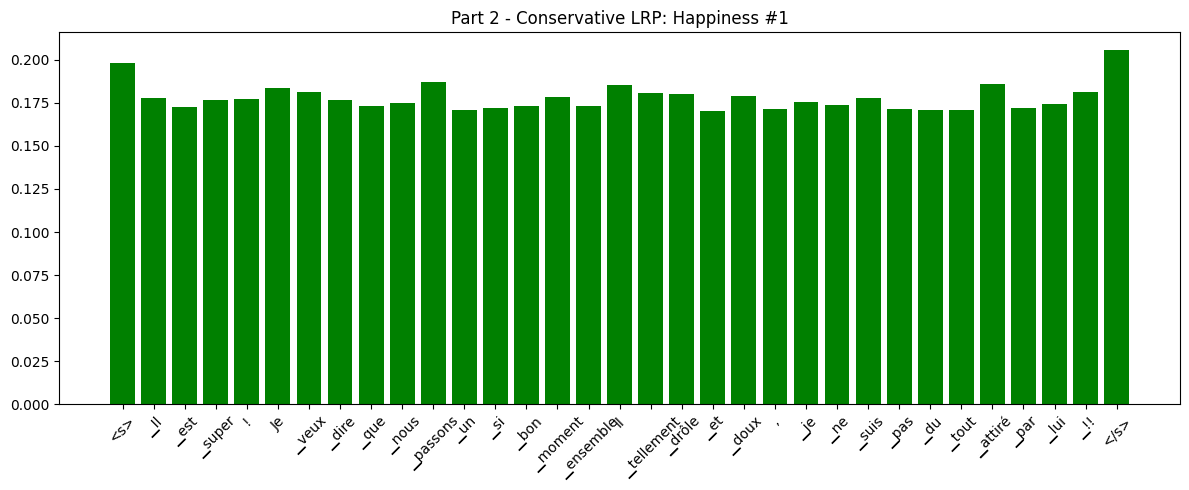

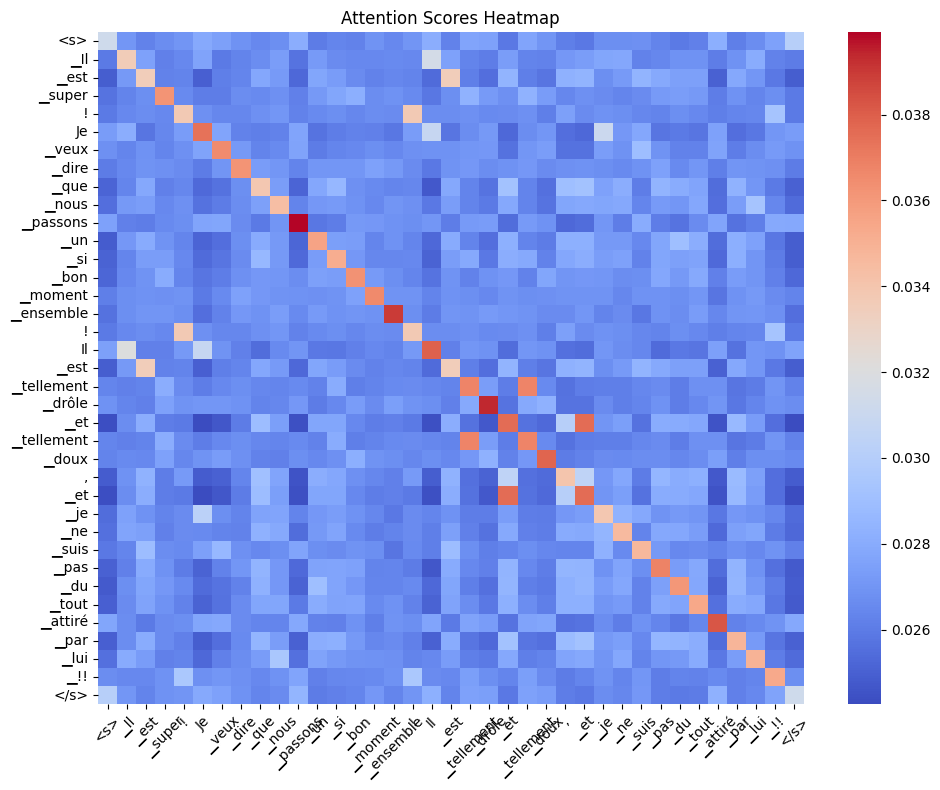

<Figure size 640x480 with 0 Axes>

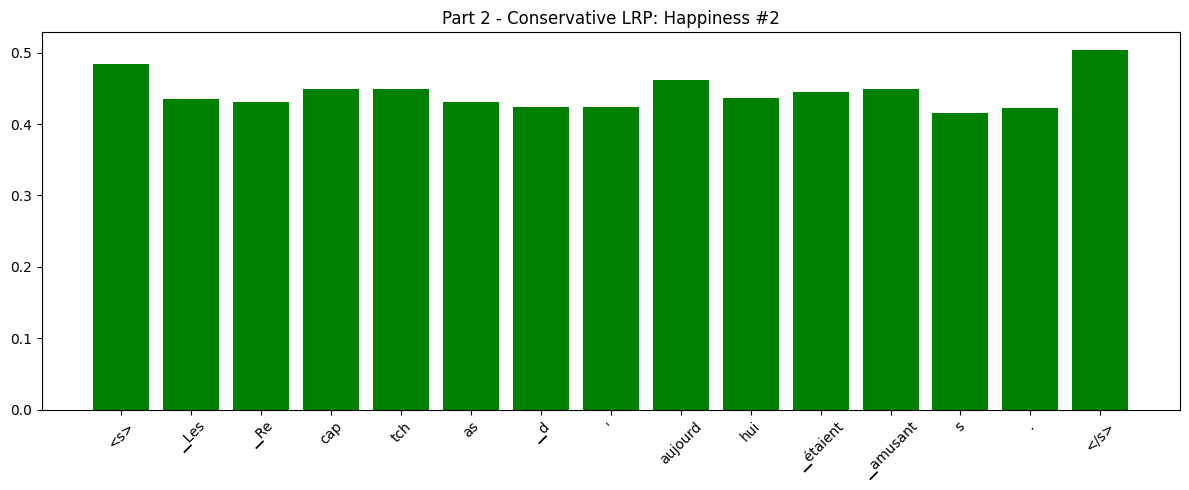

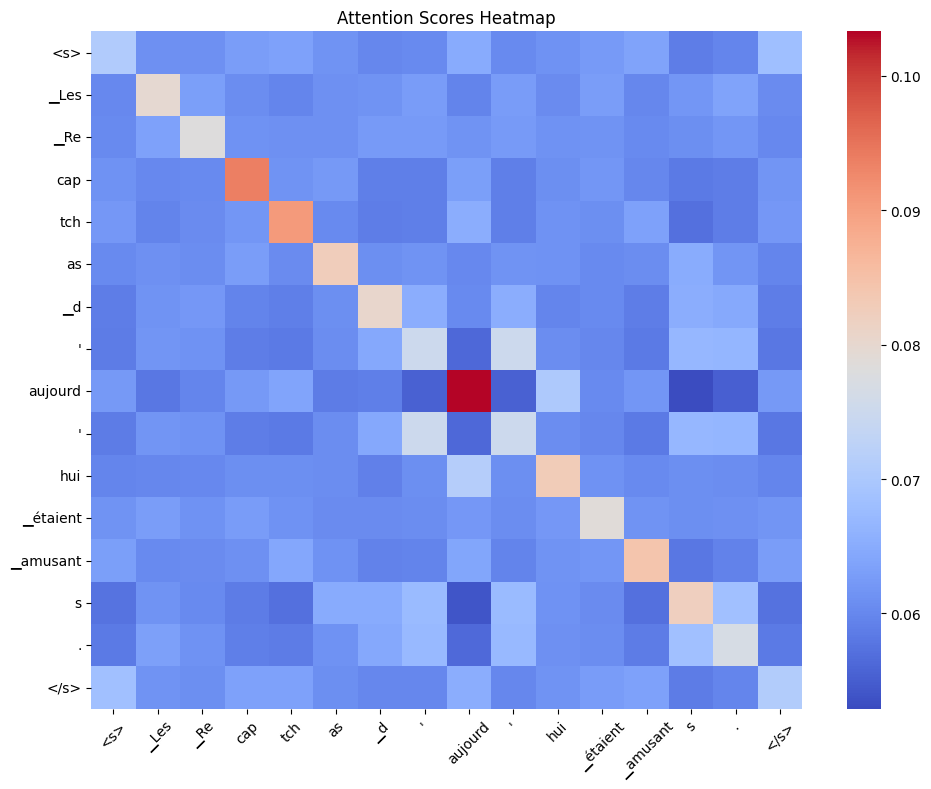

<Figure size 640x480 with 0 Axes>

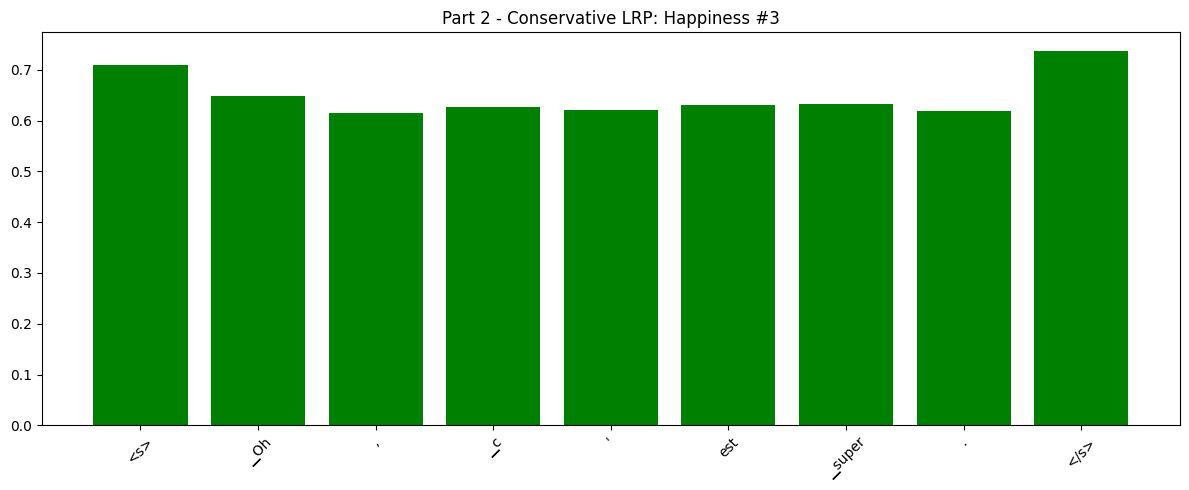

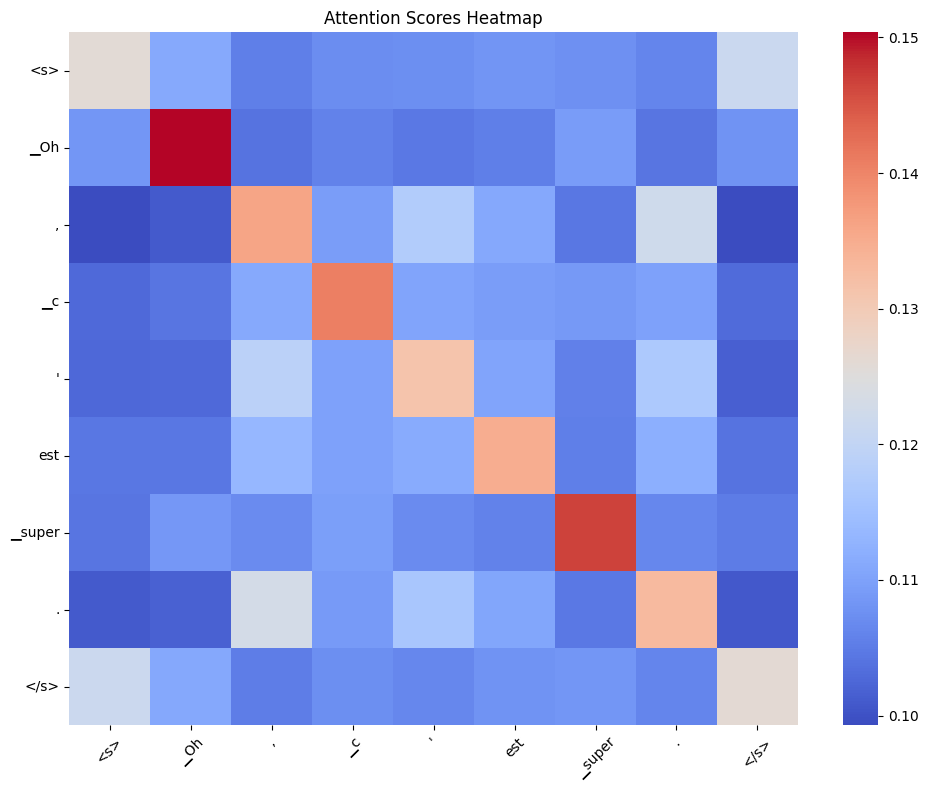

<Figure size 640x480 with 0 Axes>

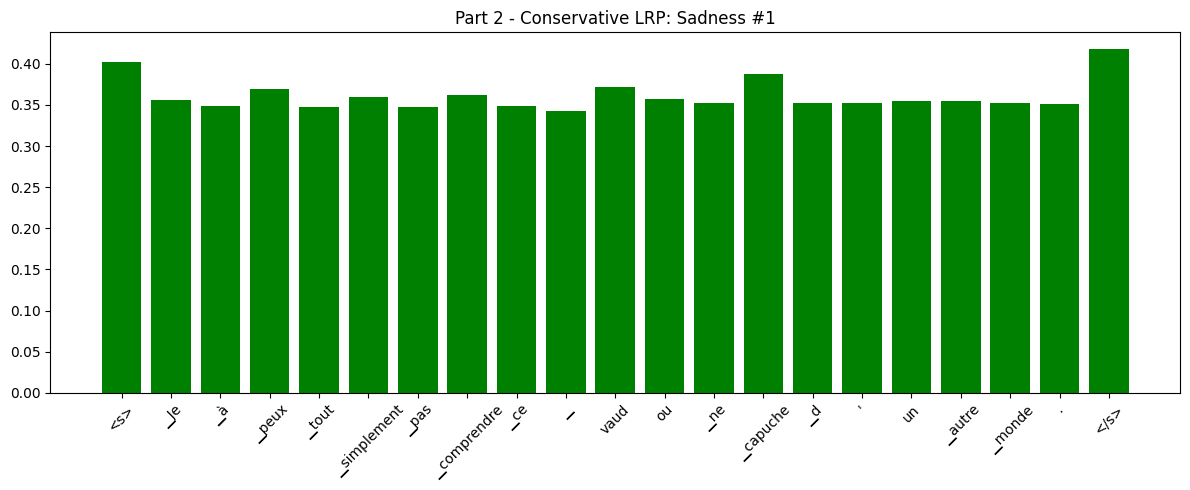

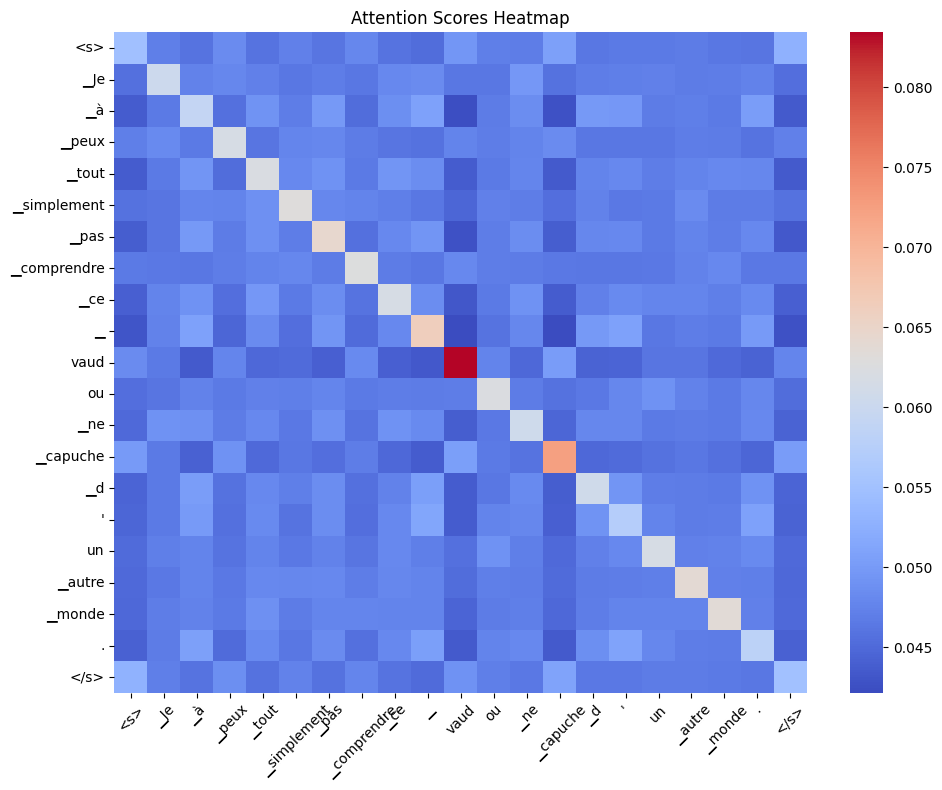

<Figure size 640x480 with 0 Axes>

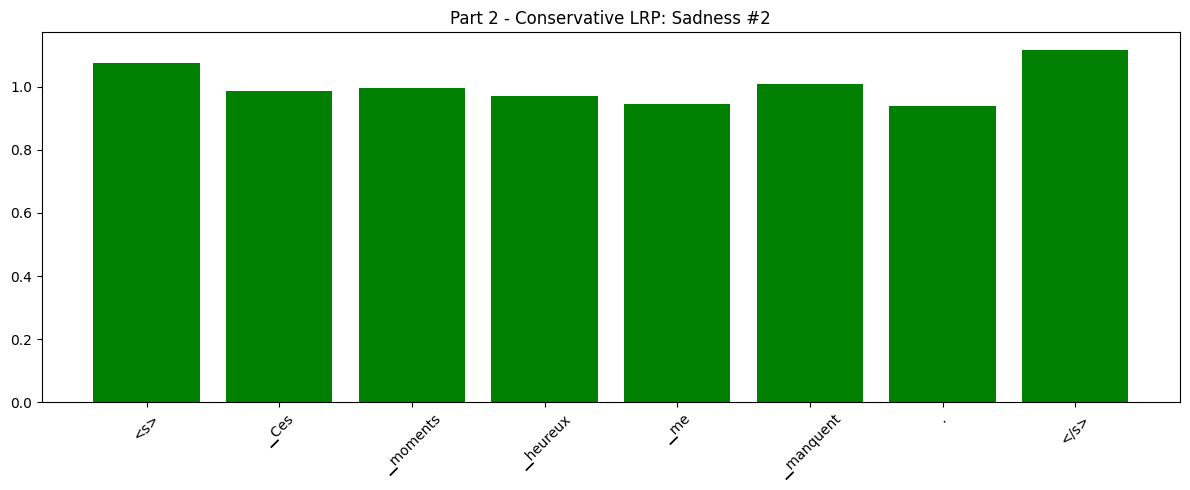

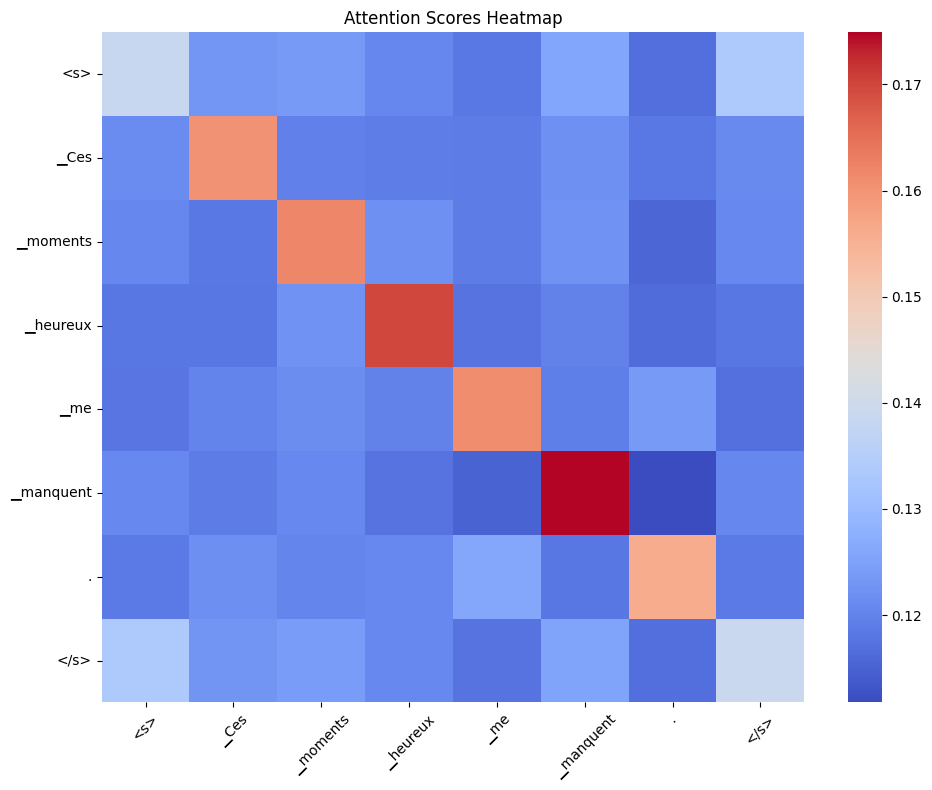

<Figure size 640x480 with 0 Axes>

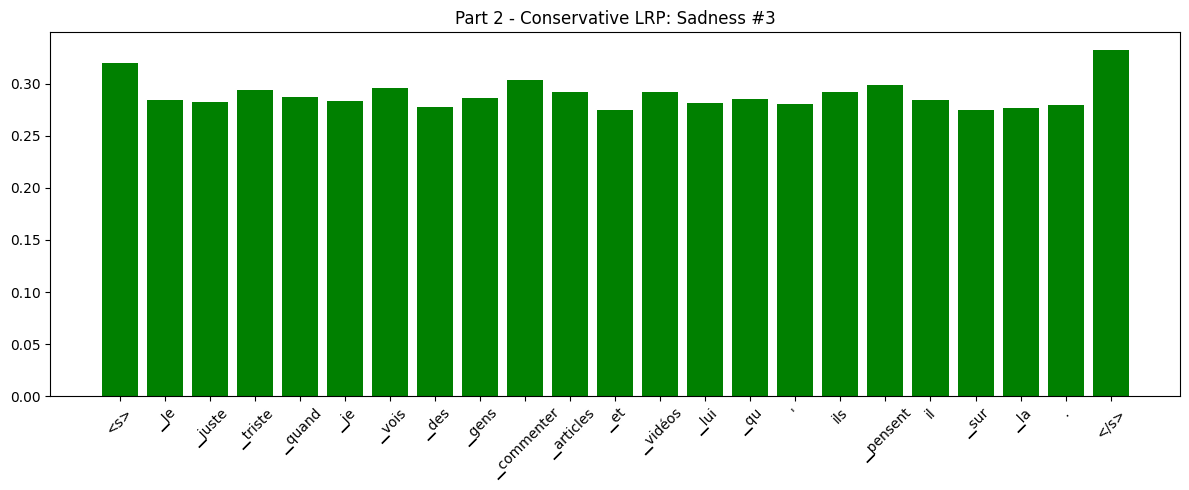

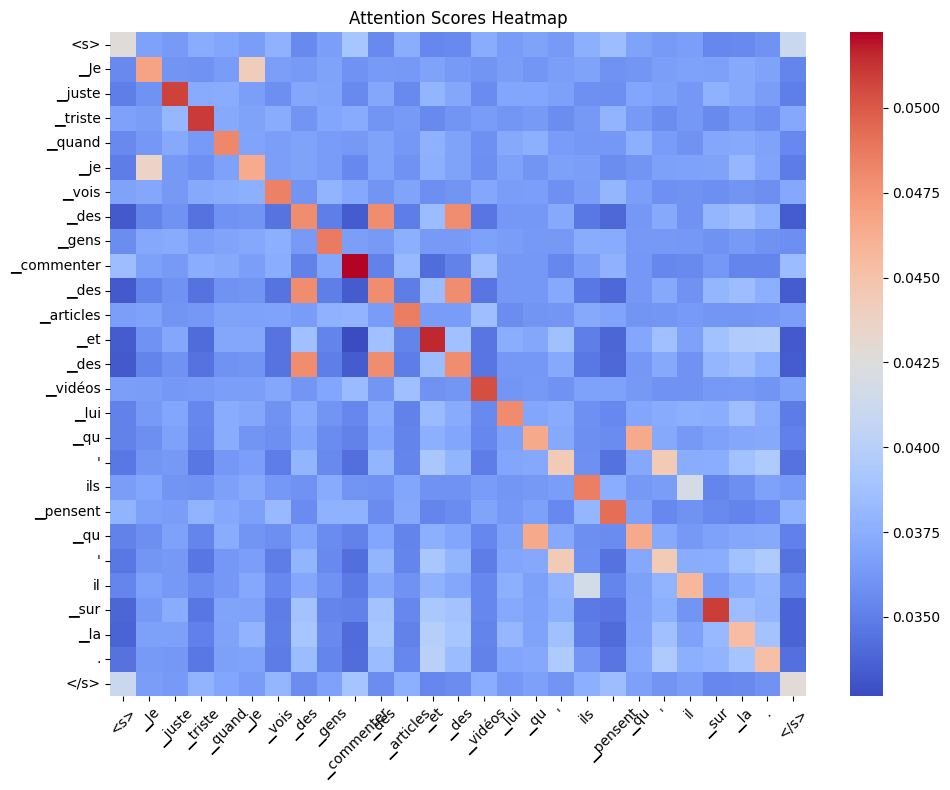

<Figure size 640x480 with 0 Axes>

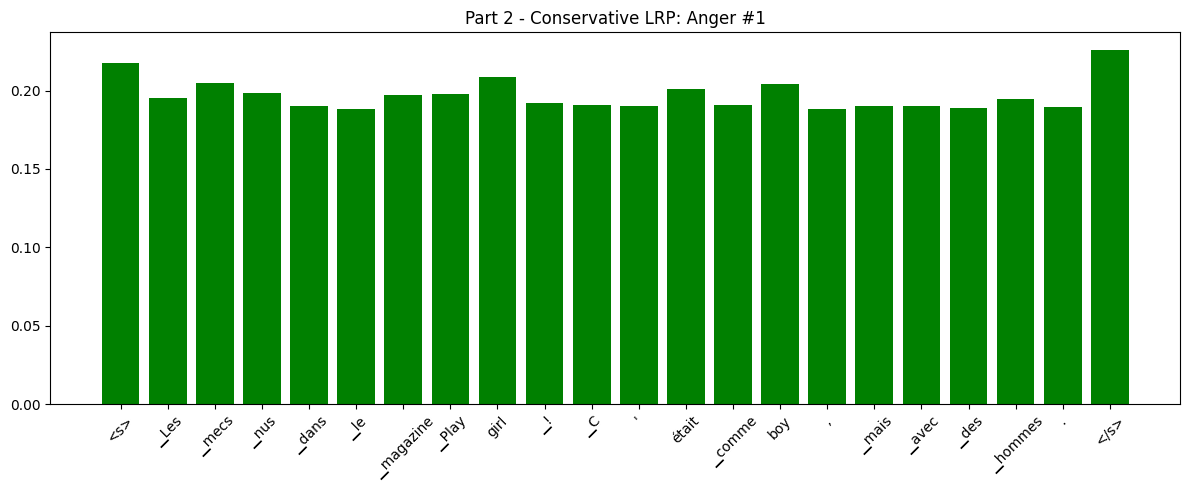

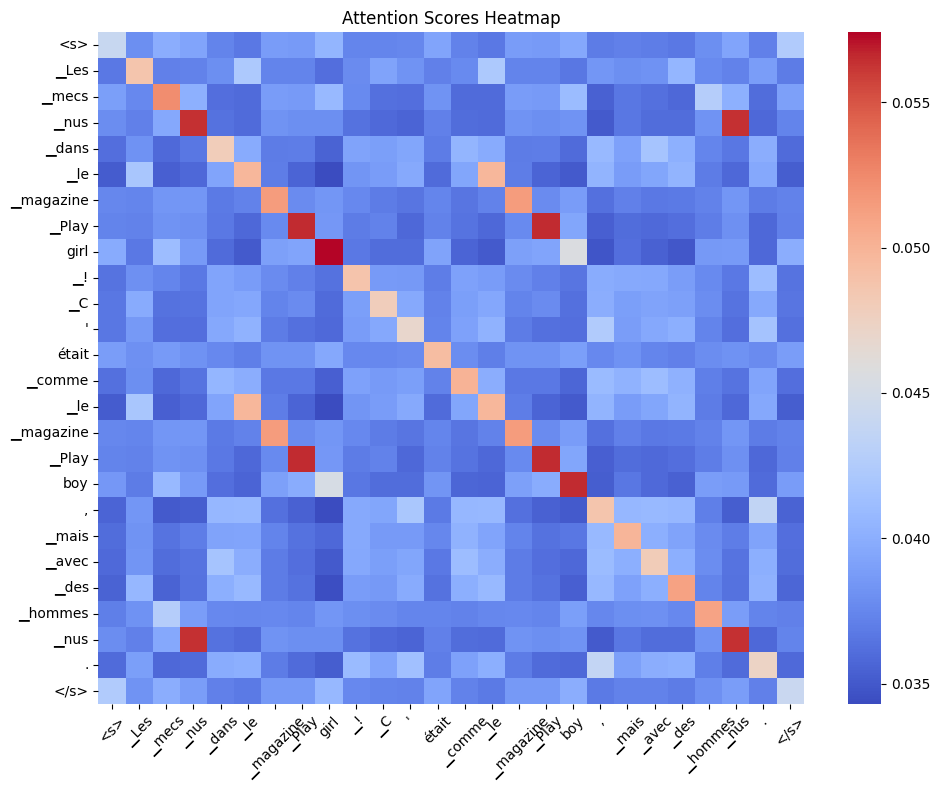

<Figure size 640x480 with 0 Axes>

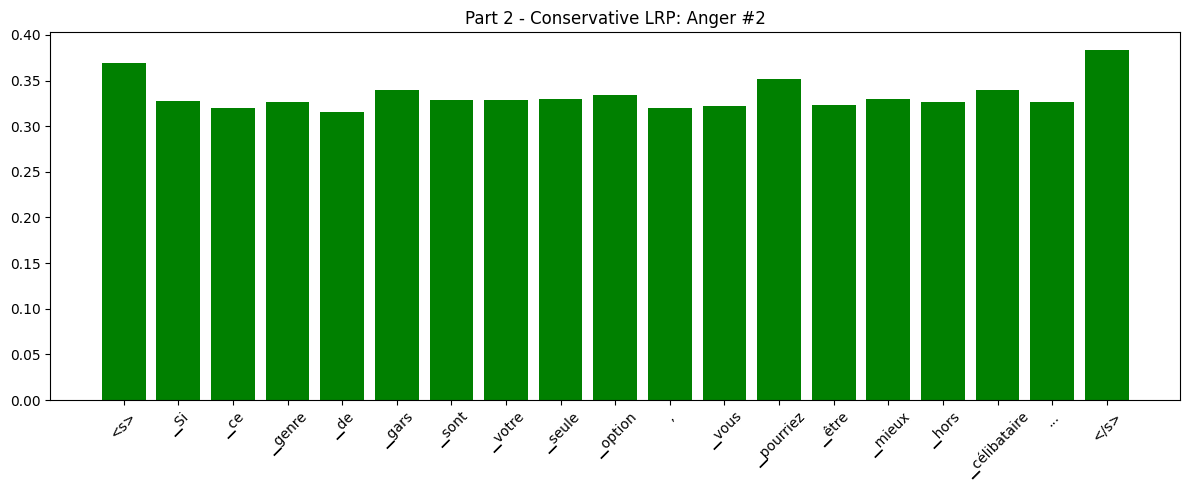

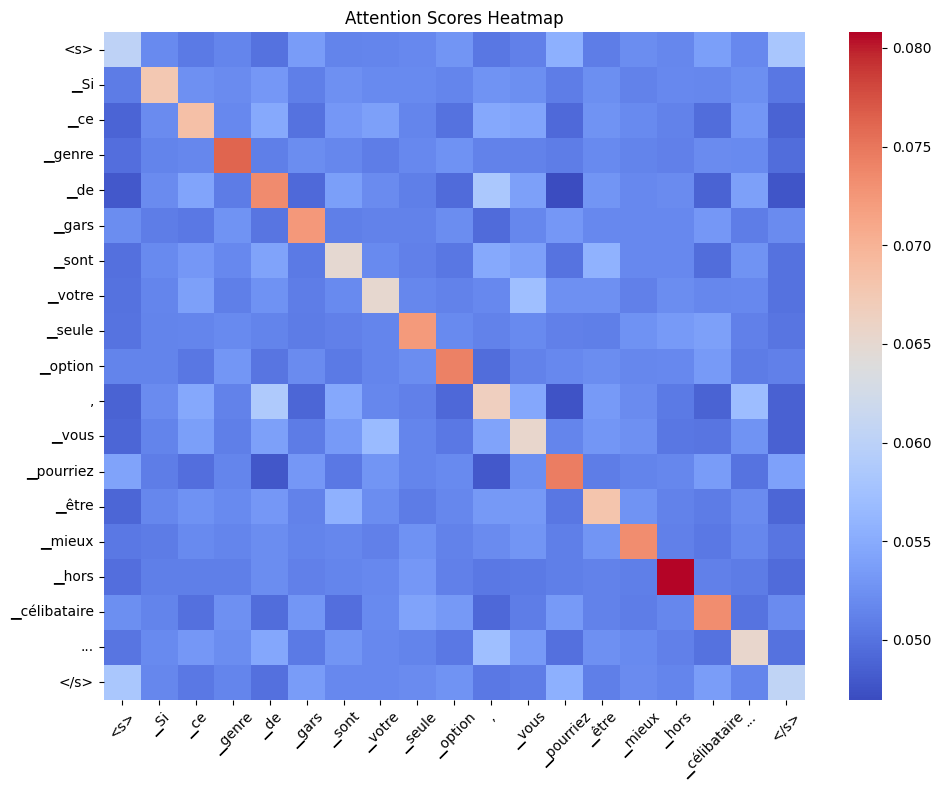

<Figure size 640x480 with 0 Axes>

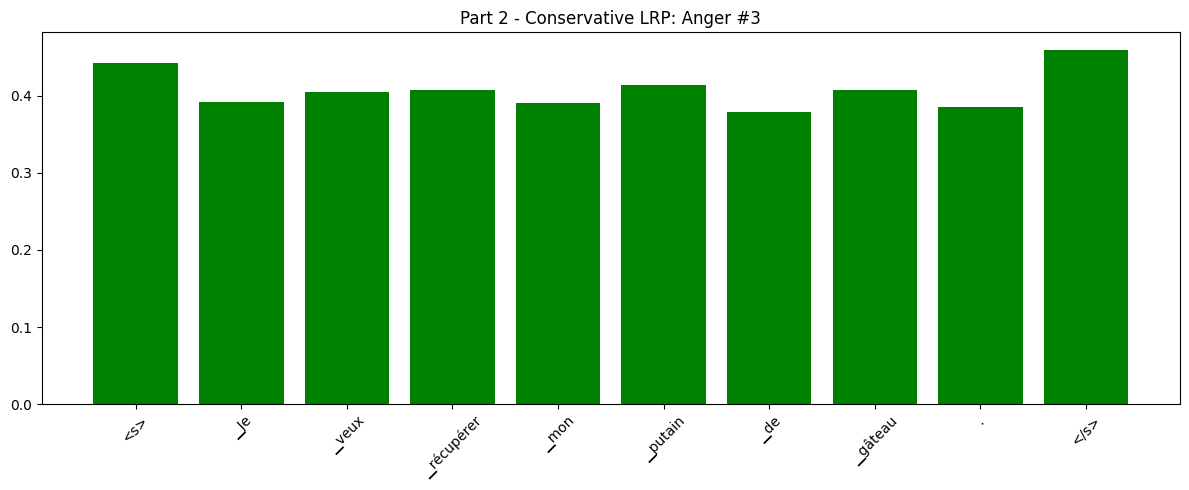

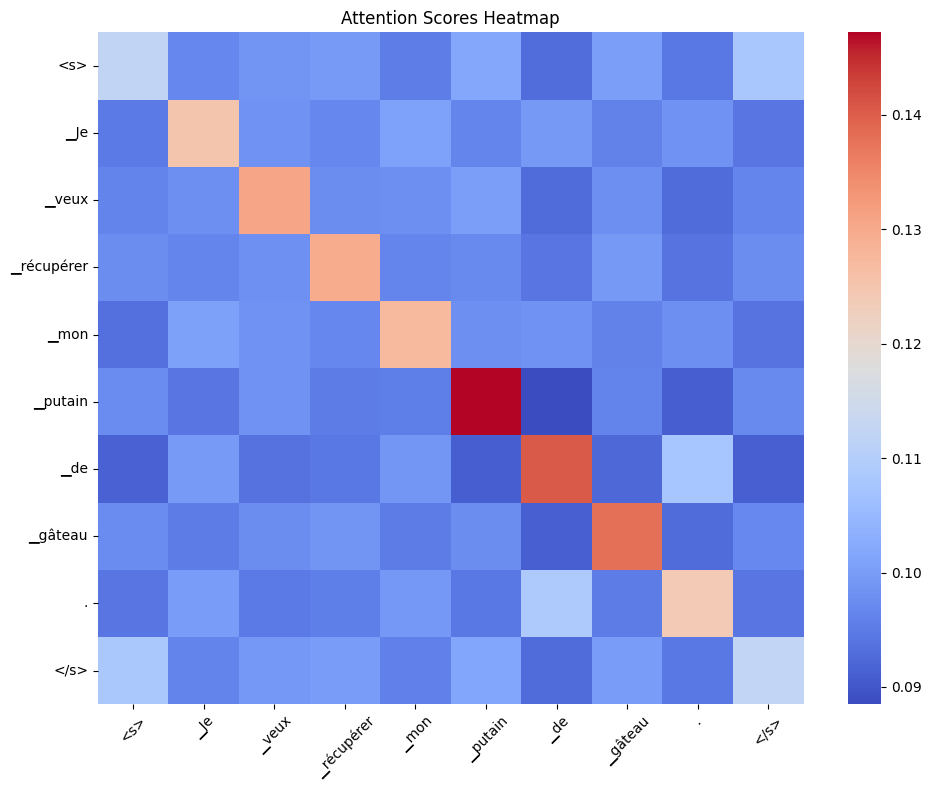

<Figure size 640x480 with 0 Axes>

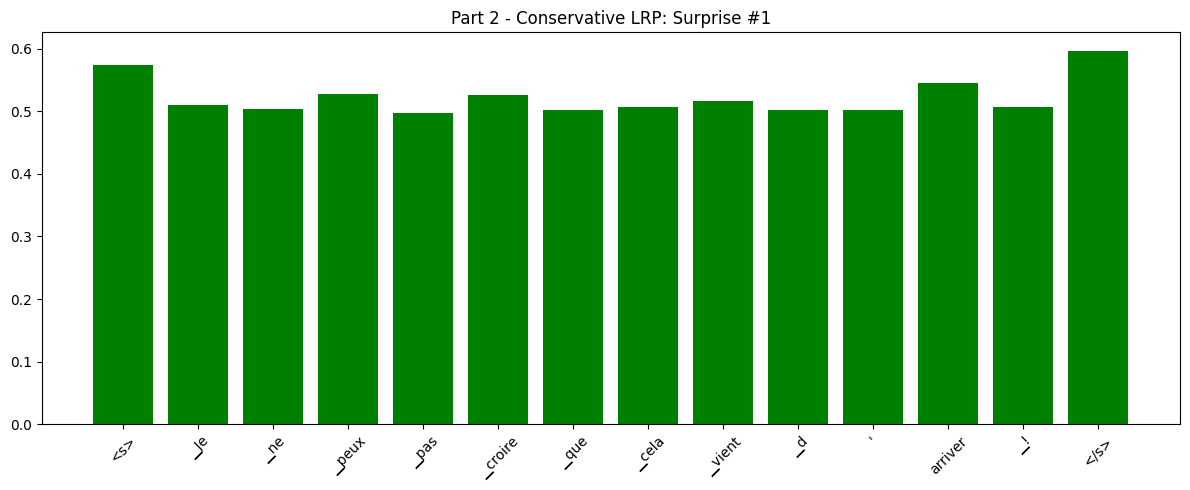

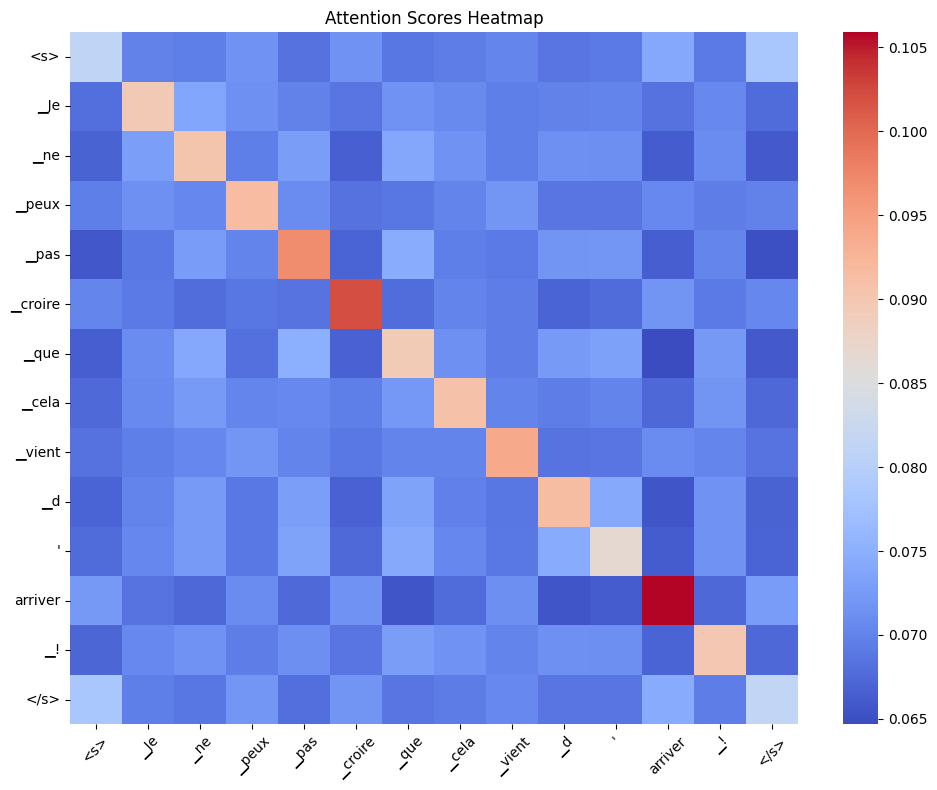

<Figure size 640x480 with 0 Axes>

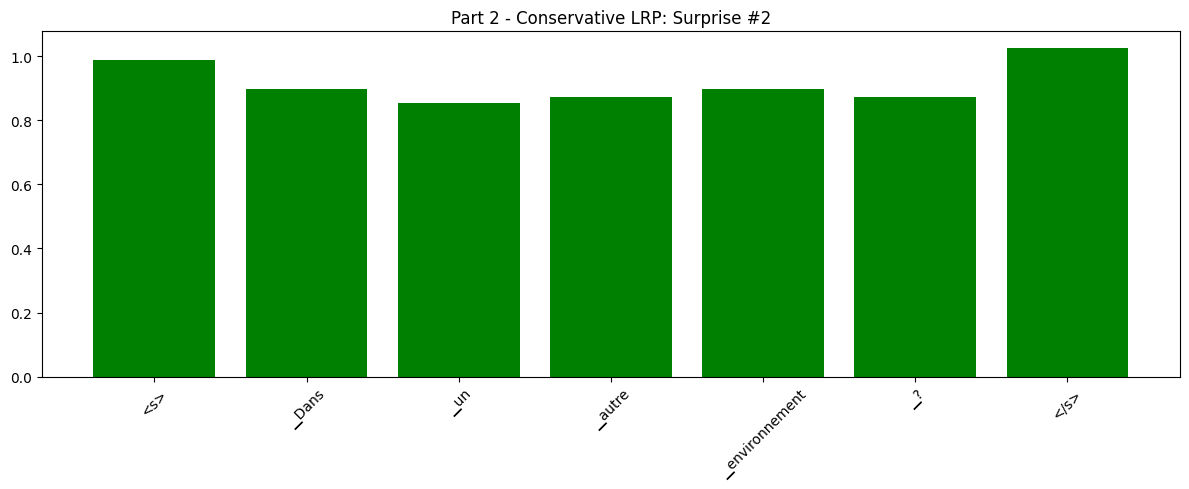

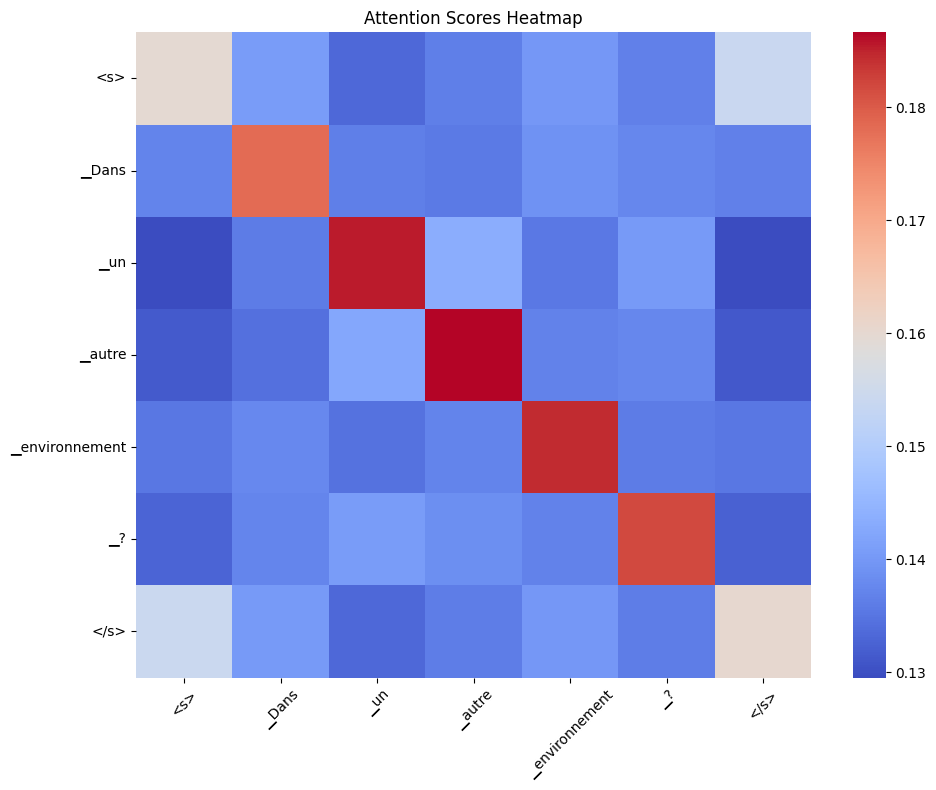

<Figure size 640x480 with 0 Axes>

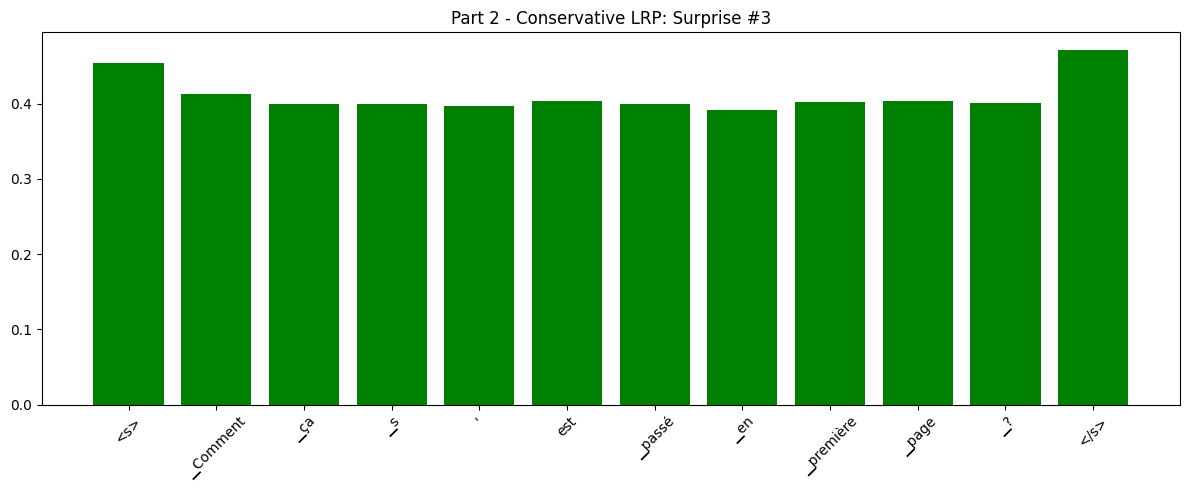

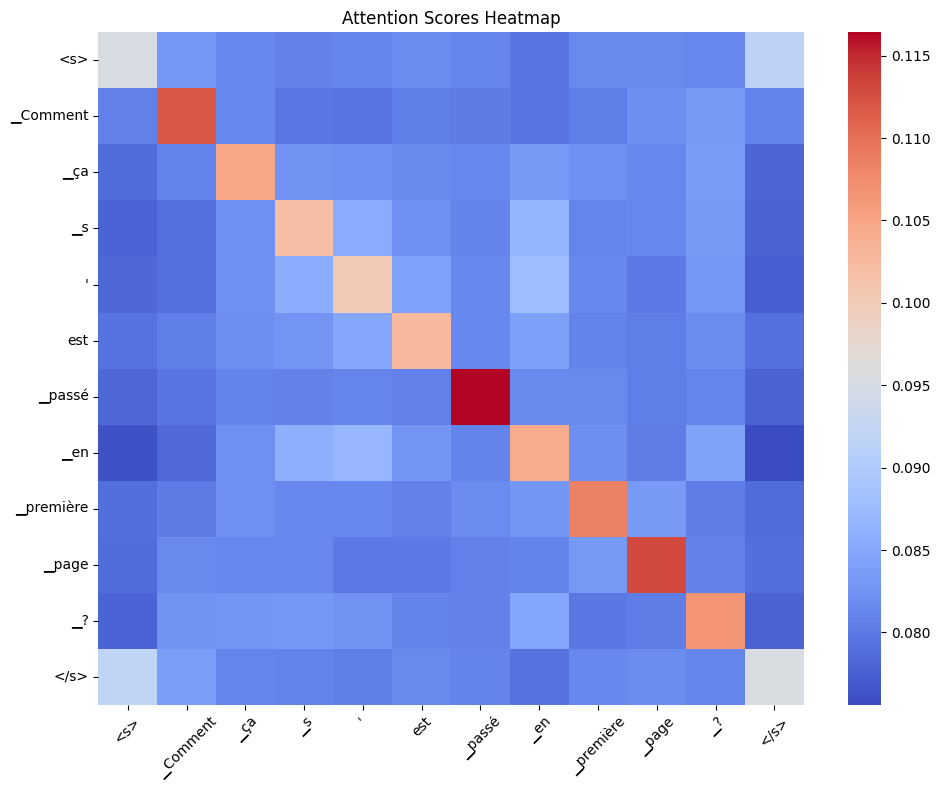

<Figure size 640x480 with 0 Axes>

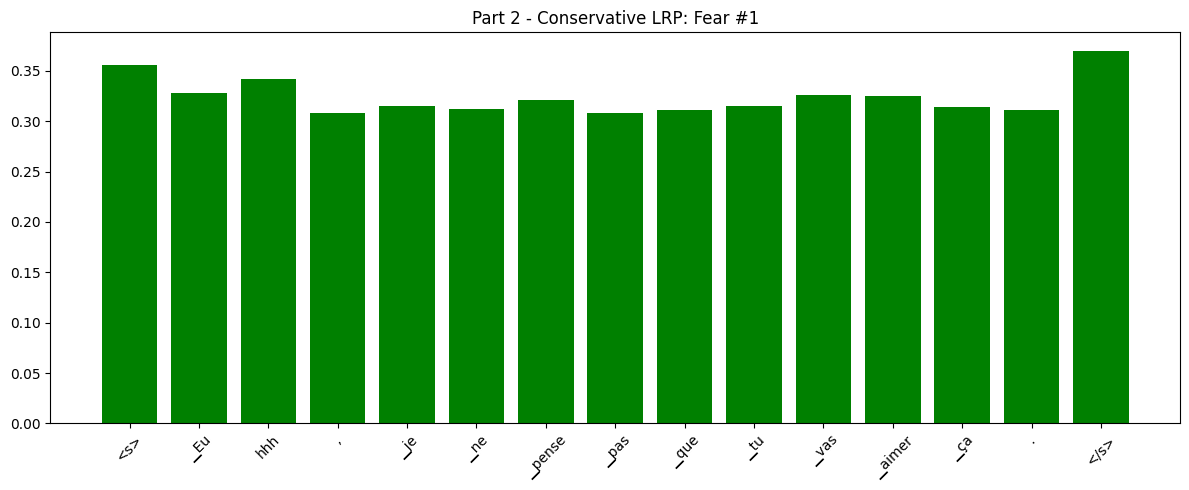

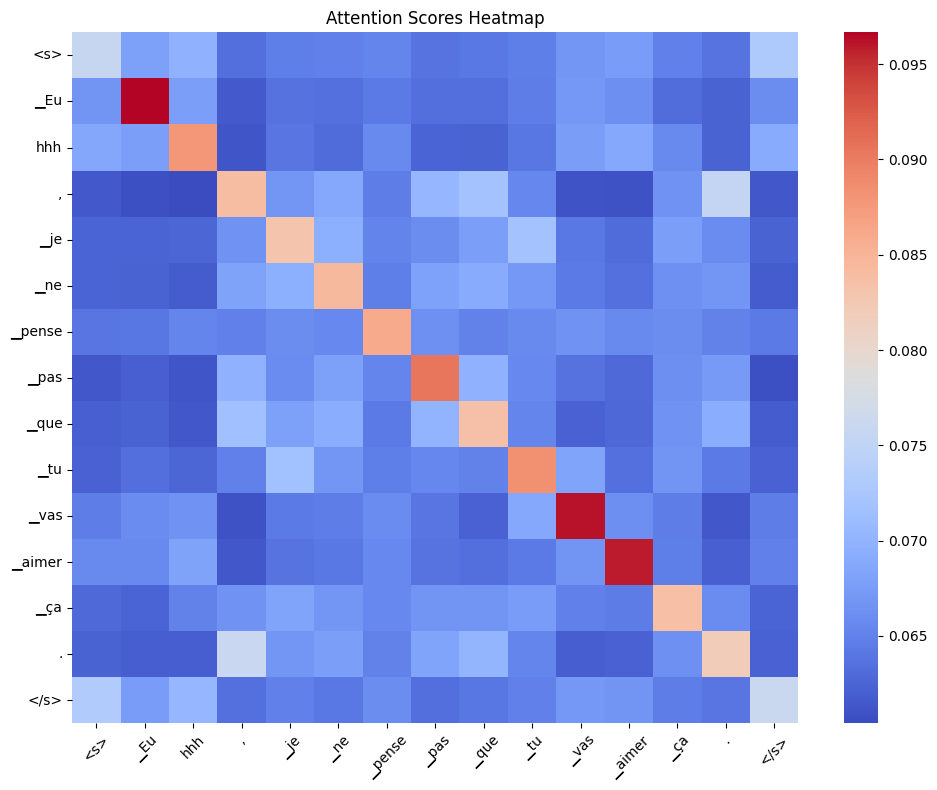

<Figure size 640x480 with 0 Axes>

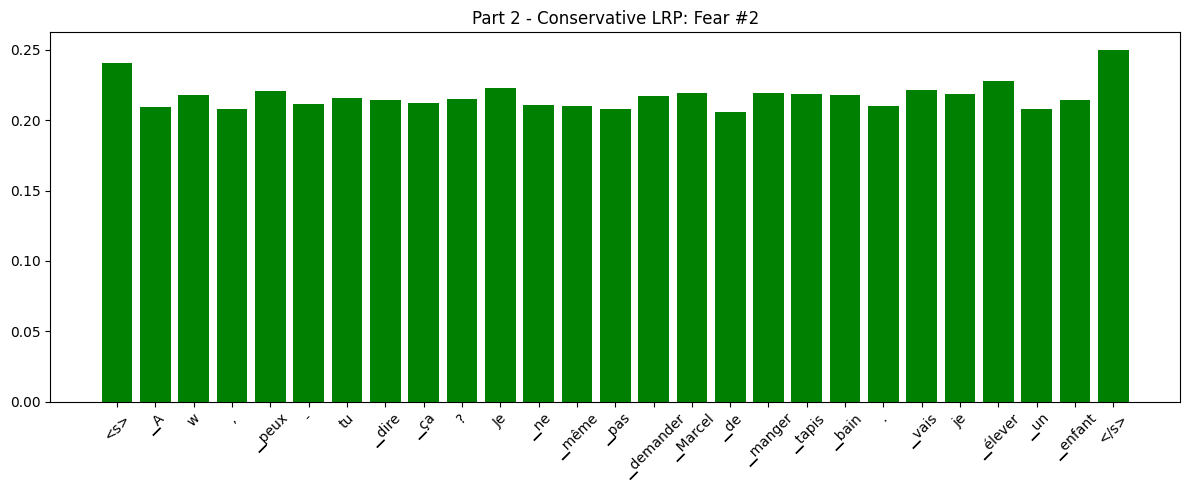

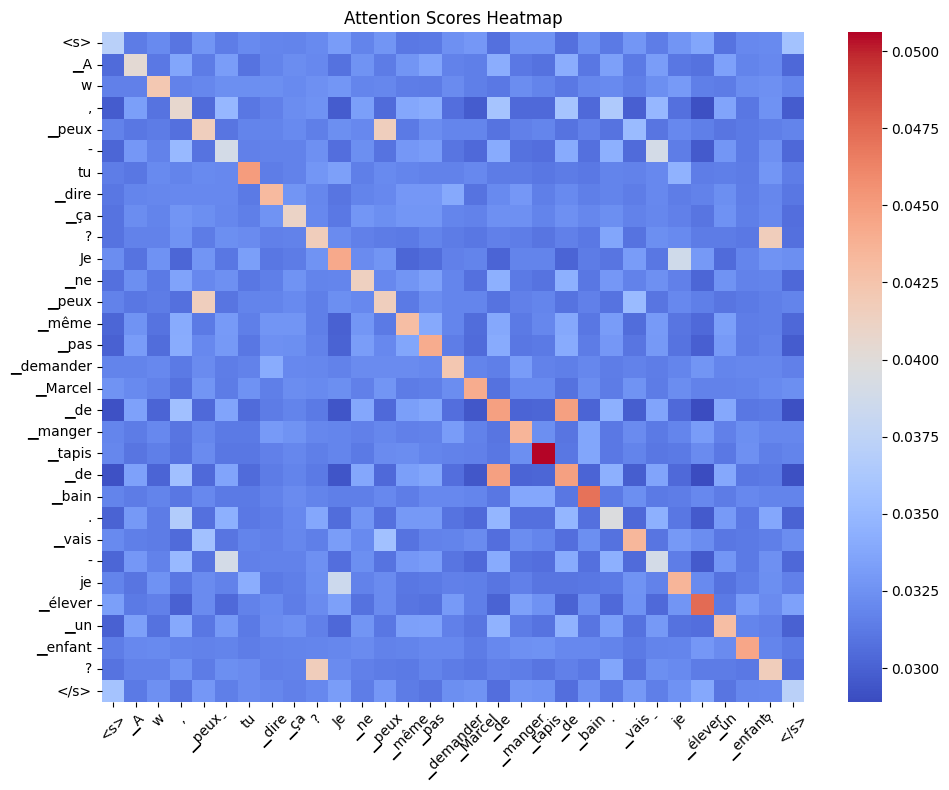

<Figure size 640x480 with 0 Axes>

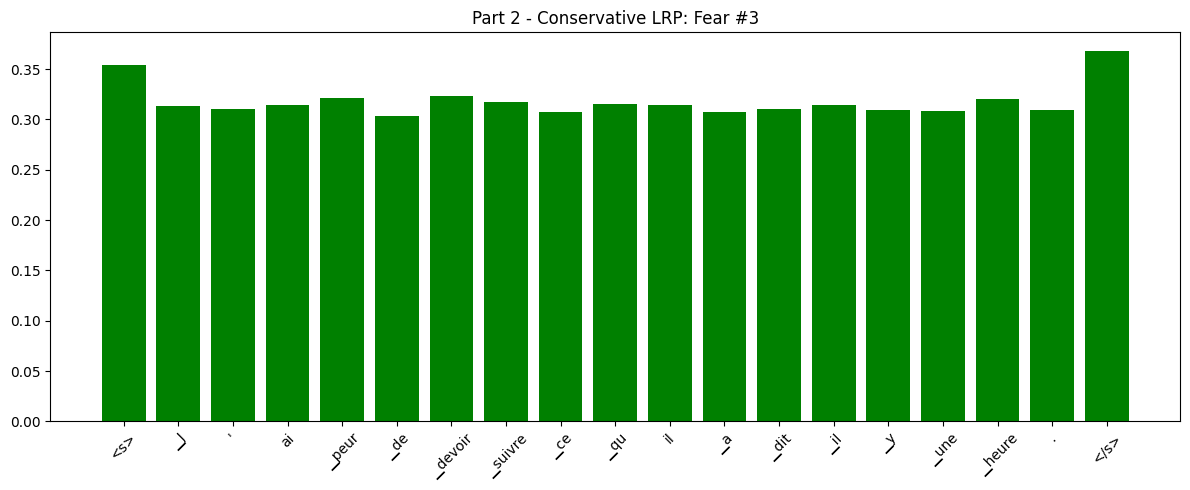

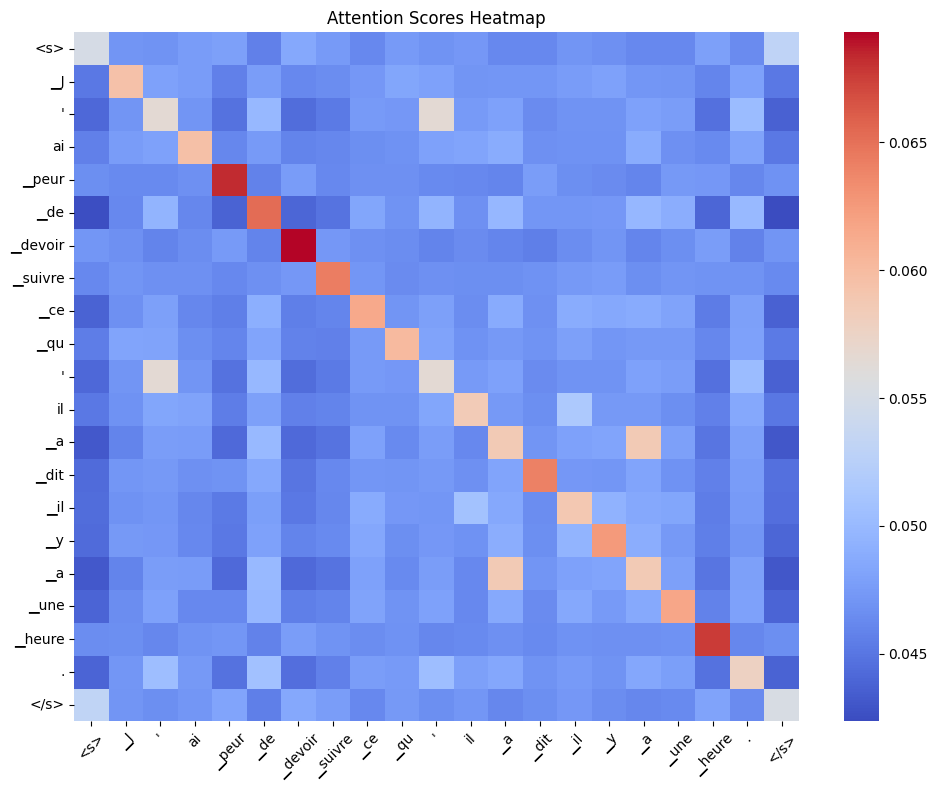

<Figure size 640x480 with 0 Axes>

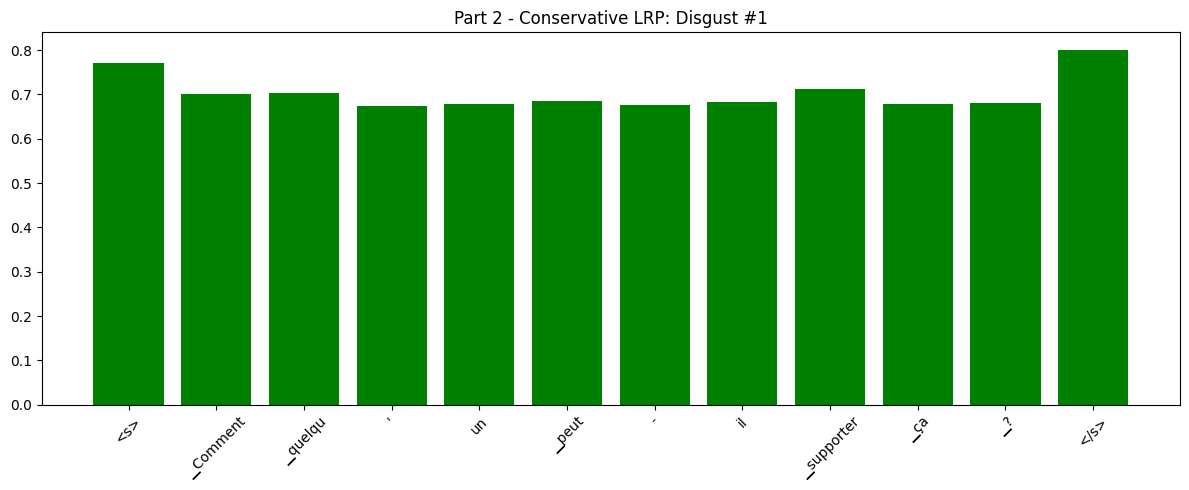

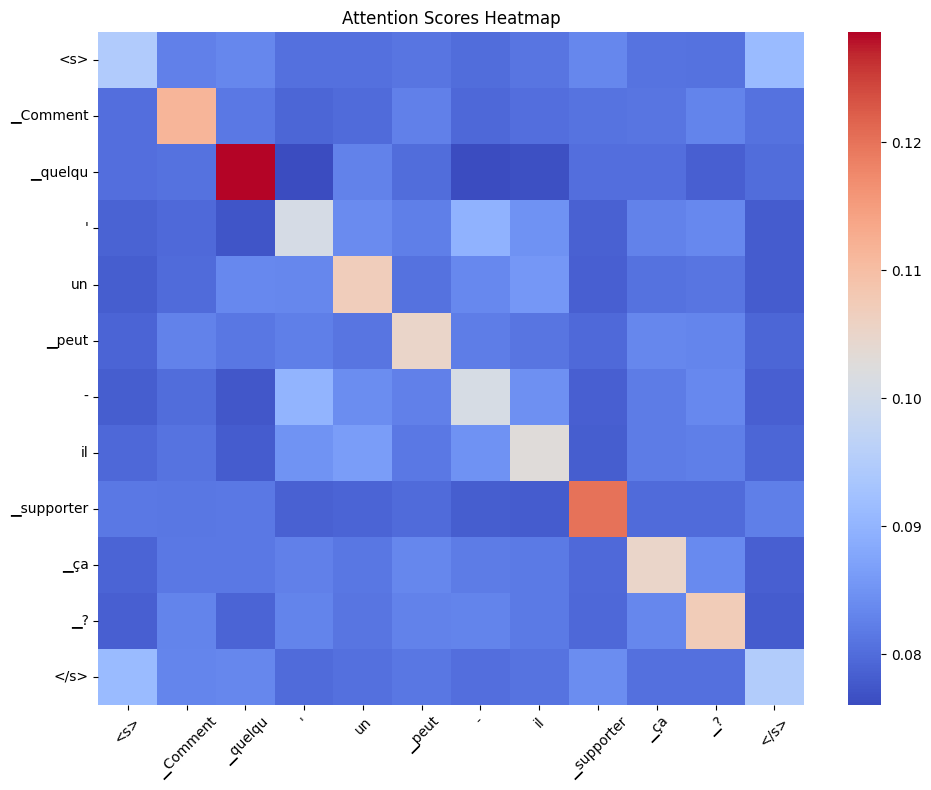

<Figure size 640x480 with 0 Axes>

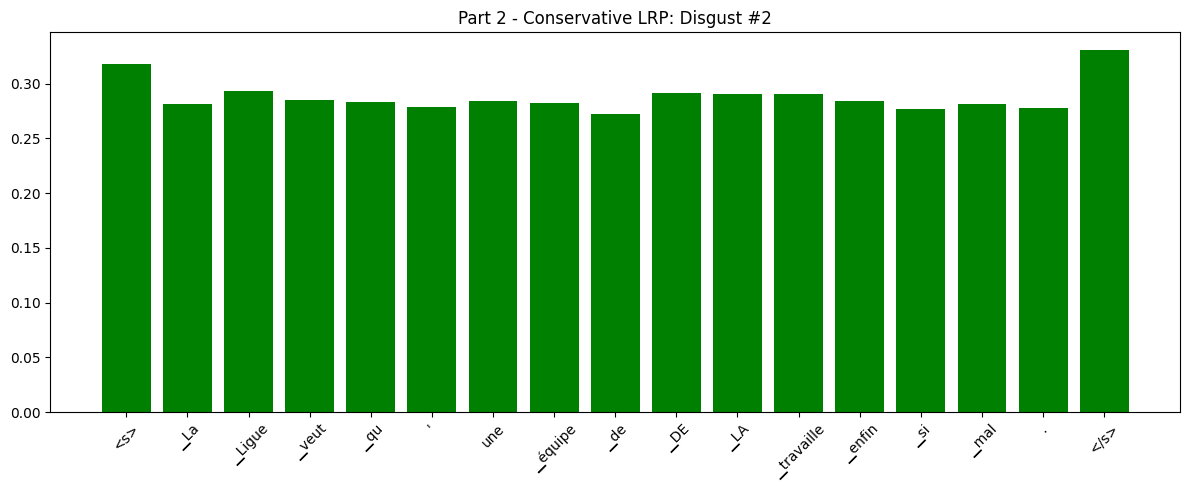

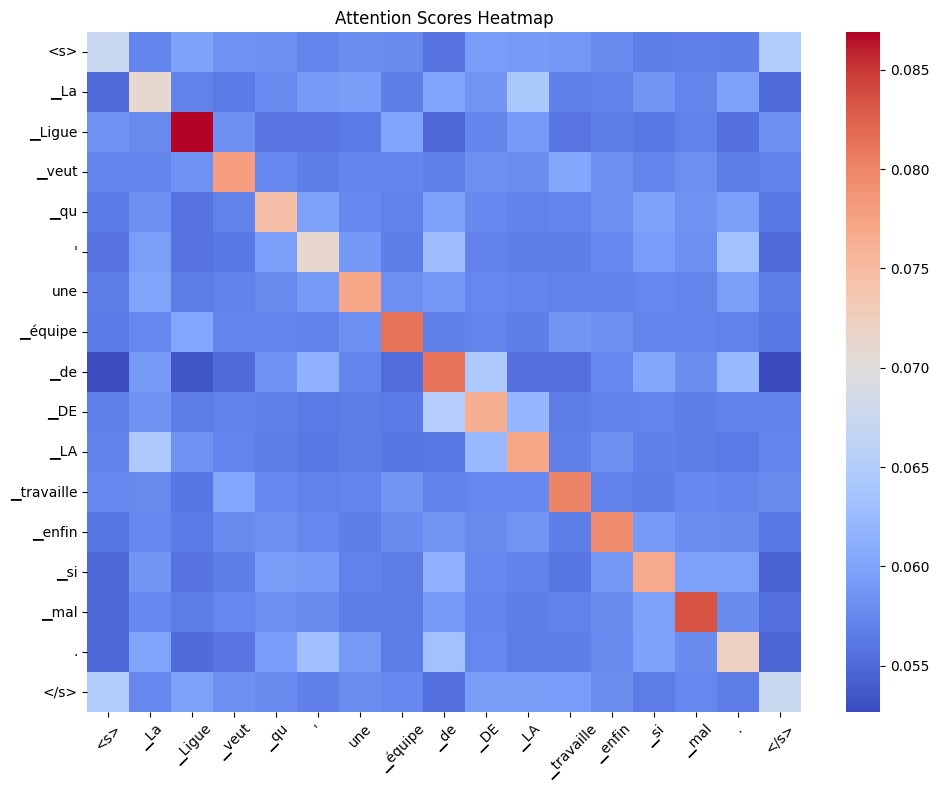

<Figure size 640x480 with 0 Axes>

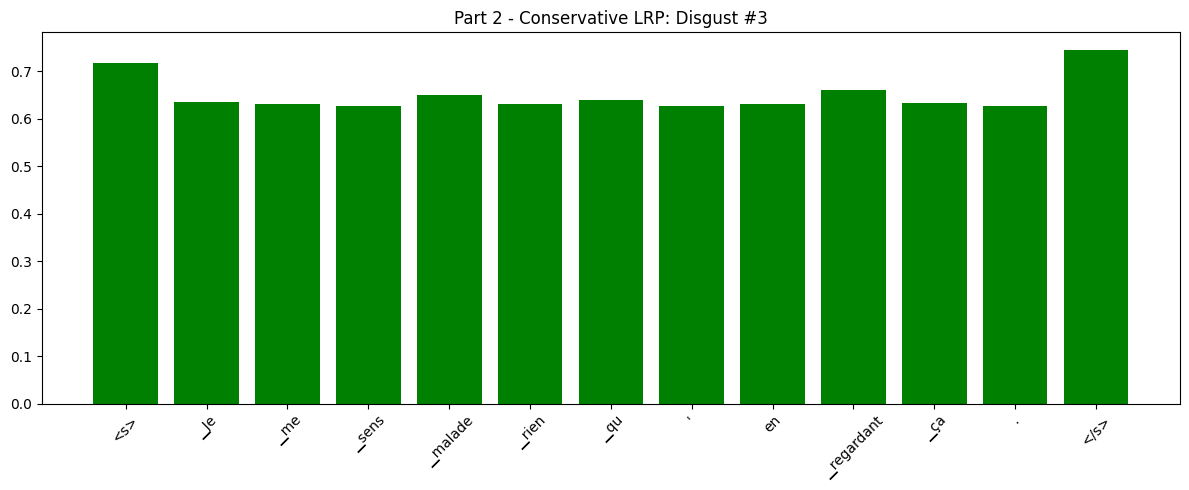

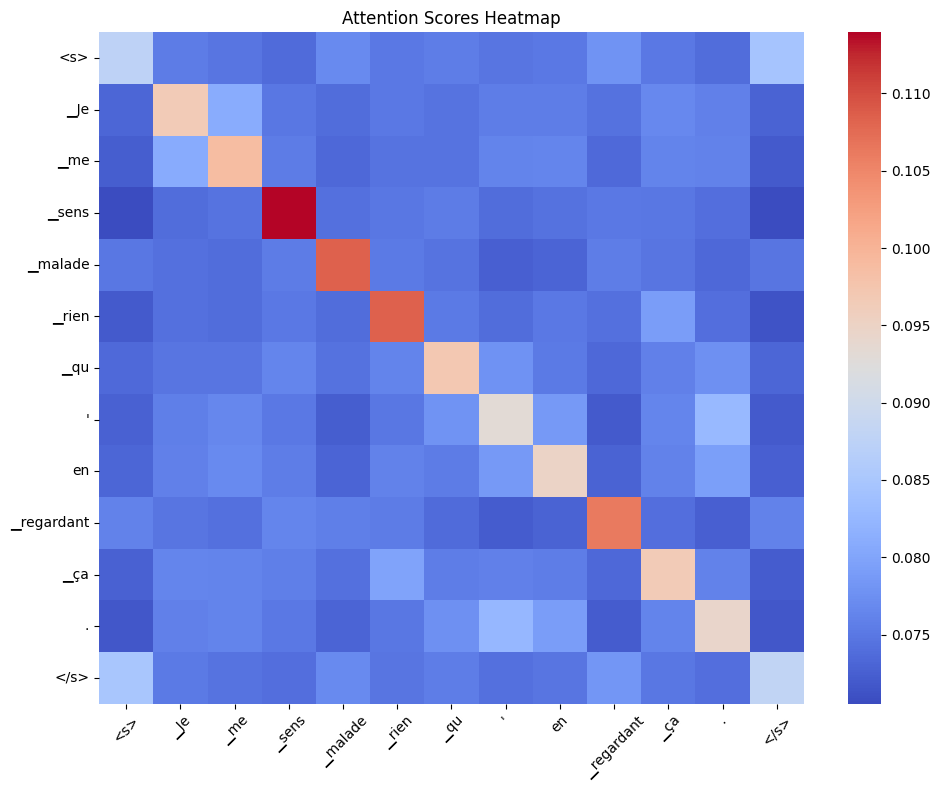

<Figure size 640x480 with 0 Axes>

In [4]:
# Output directory
output_dir = "outputs/part2_lrp"
os.makedirs(output_dir, exist_ok=True)

# Process each sentence with Conservative Propagation
for emotion, sentence_list in sentences_by_emotion.items():
    for idx, sentence in enumerate(sentence_list):
        # Tokenize input
        inputs = tokenizer(sentence, return_tensors='pt')
        tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])
        hidden_states = model.get_input_embeddings()(inputs.input_ids).clone().detach().requires_grad_(True)

        # Forward pass
        outputs = model(inputs_embeds=hidden_states, attention_mask=inputs.attention_mask)
        pred_class = outputs.logits.argmax(dim=-1)

        # Initialize relevance at output logit
        relevance = torch.zeros_like(hidden_states)
        relevance[:, -1, :] = outputs.logits[:, pred_class].unsqueeze(-1)

        # Conservative propagation (first attention layer only)
        context_layer, propagated_relevance, attention_probs = modified_attention_forward(hidden_states, relevance)

        # Relevance scores for bar chart
        scores = propagated_relevance[0].detach().numpy()[:, 0]
        colors = ['green' if s > 0 else 'red' for s in scores]

        # Plot token relevance bar chart
        plt.figure(figsize=(12, 5))
        plt.bar(tokens, scores, color=colors)
        plt.title(f"Part 2 - Conservative LRP: {emotion.capitalize()} #{idx+1}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        plt.savefig(f"{output_dir}/{emotion}_{idx+1}_relevance.png")
        plt.close()

        # Plot attention heatmap
        heatmap_path = f"{output_dir}/{emotion}_{idx+1}_attention.png"
        visualize_attention_and_relevance(attention_probs[0], tokens, save_path=heatmap_path)
